# Testing the model

In [1]:
# Set the base dir to the project root
%cd ..
!pwd

/home/pere.carrillo/micromamba/envs/pbi/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/data/pere.carrillo/pbi
/data/pere.carrillo/pbi


In [109]:
import torch
import pandas as pd
import os
from pbi_utils.data_manager import H5pyEmbeddingsManager, PerphectDataInput, EmbeddingsManager
from pbi_models.classifiers.MLP import BasicMLPClassifier
from main import parse_config, reduce_dimensionality, train_model, test_model, Stats, make_dataset, compute_metrics, logger
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [100]:
config = parse_config(config_path="model_configs/temporal_best_env.yaml")

device = config.device

[DEBUG] Max sequence length for DNABERT2: 32768
[DEBUG] Max sequence length for DNABERT2: 32768
[INFO] Configuration loaded from model_configs/temporal_best_env.yaml: Config(input_perphect=bacteria_df='data/perphect-data/all/bacteria_df.csv' phages_df='data/perphect-data/all/phages_df.csv' couples_df='data/perphect-data/all-private-oversampled/couples_df.csv', embeddings_dir=data/embeddings, num_gpu=0, gpu_id=3, training_config=TrainingConfig(do_train=True epochs=100 batch_size=256 learning_rate=0.001 weight_decay=0.0001 k_folds_cv=10 patience_early_stopping=100 monitor_metric_early_stopping='f1' patience_reduce_lr=100 monitor_metric_reduce_lr='f1' multiplying_factor_reduce_lr=0.5 reduce_dimensionality='PCA' n_components_bacteria=500 n_components_phages=500), phages_embedding_models=[NT2(merging_strategy=TopBottomTruncateStrategy(), overlap=0, model_name='nucleotide-transformer-v2-250m-multi-species'), MegaDNA(merging_strategy=MaxStrategy(), overlap=0, get_layer='concat'), DNABERT2(mer

### Load dataset

In [101]:
# Assumming that all the embeddings have already been computed
output_manager = H5pyEmbeddingsManager(config.embeddings_dir)

[INFO] Embeddings will be stored or read from data/embeddings


In [102]:
bacteria_df, phages_df, couples_df = PerphectDataInput(input_paths=config.input_perphect).load()

[INFO] Perphect input files will be read from data/perphect-data/all/bacteria_df.csv, data/perphect-data/all/phages_df.csv and data/perphect-data/all-private-oversampled/couples_df.csv
[INFO] Reading csv files...


[INFO] Creating dataset (loading embeddings)...
[DEBUG] Loading 10300 embeddings for model NT2-TopBottomTruncateStrategy-250M-ov0 from data/embeddings


Loading embeddings:   0%|          | 0/10300 [00:00<?, ?it/s]

[DEBUG] Loading 10300 embeddings for model MegaDNA-BottomTruncateStrategy-concat-ov0 from data/embeddings


Loading embeddings:   0%|          | 0/10300 [00:00<?, ?it/s]

[DEBUG] Loading 10300 embeddings for model DNABERT2-TopBottomTruncateStrategy-ov0-maxlen32768 from data/embeddings


...

[DEBUG] Loading 10300 embeddings for model MegaDNA-MaxStrategy-concat-ov0 from data/embeddings


Loading embeddings:   0%|          | 0/10300 [00:00<?, ?it/s]

[DEBUG] Loading 10300 embeddings for model DNABERT2-TKPert-concat-J16-g20-ov0-maxlen32768 from data/embeddings


Loading embeddings:   0%|          | 0/10300 [00:00<?, ?it/s]

[DEBUG] Final embedding size (bacteria): 4036
[DEBUG] Final embedding size (phages): 14788
[DEBUG] Embedding size (After dimensionality reduction) (bacteria): 500
[DEBUG] Embedding size (After dimensionality reduction) (phages): 500


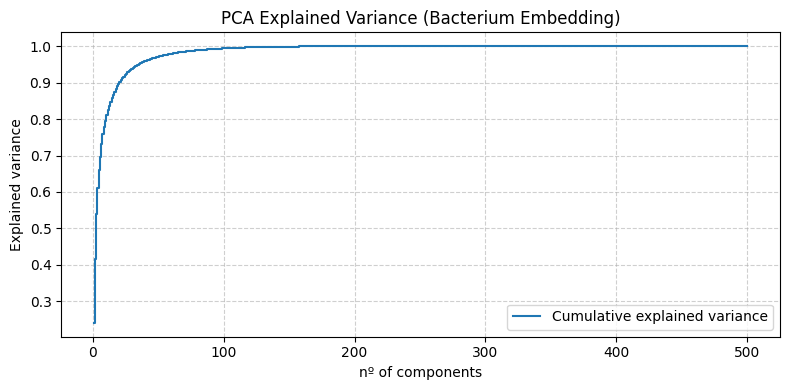

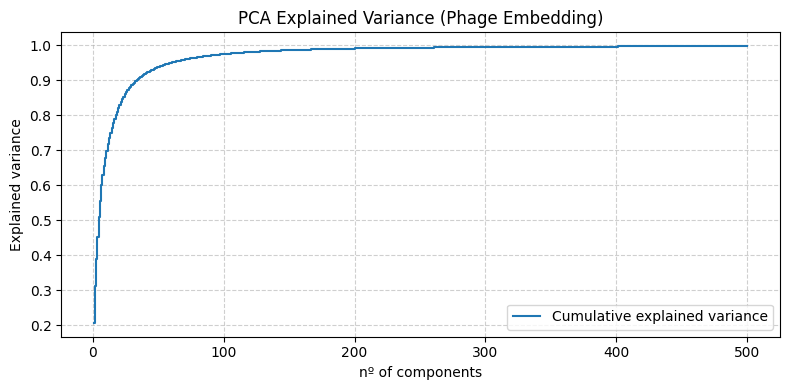

In [103]:
bacteria_model_names = [x.name() for x in config.bacteria_embedding_models]
phages_model_names = [x.name() for x in config.phages_embedding_models]
dataset = make_dataset(couples_df, bacteria_model_names, phages_model_names, output_manager, device)
dataset = reduce_dimensionality(dataset, config.training_config.reduce_dimensionality, config.output_dir, config.training_config.n_components_bacteria, config.training_config.n_components_phages)


In [104]:
dataset.head()

,id,phage_id,bacterium_id,interaction_type,bacterium_embedding,phage_embedding
0,5365,4968,1804,1,"[tensor(-9.7324), tensor(1.7421), tensor(4.854...","[tensor(-5.9955), tensor(1.0503), tensor(0.336..."
1,5366,4546,1804,1,"[tensor(-9.7324), tensor(1.7421), tensor(4.854...","[tensor(-6.0762), tensor(0.9267), tensor(0.208..."
2,5367,4911,1804,1,"[tensor(-9.7324), tensor(1.7421), tensor(4.854...","[tensor(-5.4159), tensor(-0.3305), tensor(3.89..."
3,5368,4200,1804,1,"[tensor(-9.7324), tensor(1.7421), tensor(4.854...","[tensor(-4.8338), tensor(-0.7513), tensor(2.86..."
4,5369,4942,1804,1,"[tensor(-9.7324), tensor(1.7421), tensor(4.854...","[tensor(-5.9018), tensor(-0.5648), tensor(3.81..."


### Load the model
Make sure to use the same architecture and parameters that were used for training it. See the yaml file that was used.

In [105]:
model_path = os.path.join(config.output_dir, "trained_model.pth")

In [106]:
bacterium_embed_size = len(dataset["bacterium_embedding"].iloc[0])
phage_embed_size = len(dataset["phage_embedding"].iloc[0])
model = config.classifier(bacterium_embed_size, phage_embed_size, **config.classifier_params)

model.load_state_dict(torch.load(model_path, map_location=device))

/home/pere.carrillo/micromamba/envs/pbi/lib/python3.10/site-packages/torch/nn/init.py:412: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


<All keys matched successfully>

### Test the model

In [107]:
randomized_ds = dataset.sample(frac=1, random_state=42).reset_index(drop=True)
test_phag_ids = randomized_ds["phage_id"].drop_duplicates().sample(n=250, random_state=25).to_list()
test_dataset = dataset[dataset["phage_id"].isin(test_phag_ids)].reset_index(drop=True)

test_dataset.head()

,id,phage_id,bacterium_id,interaction_type,bacterium_embedding,phage_embedding
0,6207,5314,5159,0,"[tensor(-0.3203), tensor(-2.7498), tensor(-0.2...","[tensor(3.2828), tensor(-1.1332), tensor(0.979..."
1,6250,5314,5165,0,"[tensor(-1.7499), tensor(-1.4014), tensor(4.81...","[tensor(3.2828), tensor(-1.1332), tensor(0.979..."
2,6293,5314,5198,0,"[tensor(0.2120), tensor(2.9530), tensor(-0.625...","[tensor(3.2828), tensor(-1.1332), tensor(0.979..."
3,6336,5314,5199,0,"[tensor(-0.1667), tensor(1.6578), tensor(-1.12...","[tensor(3.2828), tensor(-1.1332), tensor(0.979..."
4,6379,5314,5200,0,"[tensor(-0.9766), tensor(-6.2039), tensor(-0.2...","[tensor(3.2828), tensor(-1.1332), tensor(0.979..."


In [110]:
train_dataset, test_dataset = train_test_split(dataset, test_size=0.2, random_state=42, shuffle=True)

In [111]:
test_model(test_dataset, model, batch_size=config.training_config.batch_size, device=device);

[INFO] Starting testing...
[INFO] Accuracy (test): 0.9650485515594482
[INFO] Recall (test): 0.973240852355957
[INFO] F1 score (test): 0.9646365642547607
[INFO] Loss (test): 0.20405828393422162
[INFO] Confusion Matrix (test) (TP, FP, FN, TN): (982, 45, 27, 1006)


### Do 1 prediction

In [73]:
# Do 1 prediction example
example = test_dataset.iloc[0]
bacterium_embedding = example["bacterium_embedding"].clone().detach().unsqueeze(0).to(device)
phage_embedding = example["phage_embedding"].clone().detach().unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    output = model(bacterium_embedding, phage_embedding)
    probs = torch.sigmoid(output).squeeze().cpu().numpy()
    print(f"Predicted interaction probability for bacterium {example['bacterium_id']} and phage {example['phage_id']}: Label {np.argmax(probs)} with probability {np.max(probs):.6f}. True label: {example['interaction_type']}")

Predicted interaction probability for bacterium 5159 and phage 5314: Label 0 with probability 0.999950. True label: 0


### View missed predictions

In [112]:
test_dataset[["prediction", "probability"]] = test_dataset.apply(
    lambda row: pd.Series({
        "prediction": int(torch.argmax(torch.sigmoid(model(
            row["bacterium_embedding"].unsqueeze(0).to(device),
            row["phage_embedding"].unsqueeze(0).to(device)
        ))).squeeze().detach().cpu().numpy()),
        "probability": float(torch.max(torch.sigmoid(model(
            row["bacterium_embedding"].unsqueeze(0).to(device),
            row["phage_embedding"].unsqueeze(0).to(device)
        ))).squeeze().detach().cpu().numpy())
    }), axis=1
)
test_dataset.head()

,id,phage_id,bacterium_id,interaction_type,bacterium_embedding,phage_embedding,prediction,probability
5397,7899,5286,5180,1,"[tensor(-4.4061), tensor(-0.5860), tensor(8.96...","[tensor(0.5544), tensor(-1.1405), tensor(-2.52...",1.0,0.980494
3077,9255,5206,5244,1,"[tensor(-3.5581), tensor(0.6976), tensor(-3.62...","[tensor(-6.6408), tensor(-1.0821), tensor(-0.4...",1.0,0.825109
6050,7810,5283,5178,1,"[tensor(-4.5484), tensor(2.2975), tensor(8.789...","[tensor(-1.2678), tensor(-2.0181), tensor(-2.6...",1.0,0.897390
6502,1127,2318,1869,1,"[tensor(3.3656), tensor(-2.8371), tensor(0.238...","[tensor(6.8565), tensor(-0.7436), tensor(-0.07...",1.0,0.926293
3601,5366,4546,1804,1,"[tensor(-9.7324), tensor(1.7421), tensor(4.854...","[tensor(-6.0762), tensor(0.9267), tensor(0.208...",1.0,0.999776


In [113]:
test_dataset["phage_id"].value_counts()

phage_id
5281    40
5229    37
5283    35
5296    29
5286    29
        ..
3805     1
3848     1
2659     1
2831     1
2162     1
Name: count, Length: 861, dtype: int64

In [114]:
test_dataset[test_dataset["interaction_type"] != test_dataset["prediction"]]["phage_id"].value_counts()

phage_id
5293    2
5296    2
5298    2
5286    2
5319    2
       ..
5311    1
3492    1
2866    1
4587    1
3810    1
Name: count, Length: 62, dtype: int64

In [123]:
test_dataset[test_dataset["interaction_type"] != test_dataset["prediction"]]["bacterium_id"].value_counts()

bacterium_id
5859    4
1869    4
5190    4
5202    3
5192    3
5180    3
5761    3
5197    2
5792    2
5194    2
126     2
524     2
940     2
153     2
5165    1
5880    1
502     1
999     1
759     1
1780    1
5163    1
5790    1
5186    1
6270    1
5181    1
5159    1
501     1
5793    1
527     1
377     1
5734    1
5787    1
5193    1
5752    1
1738    1
5791    1
1021    1
5732    1
5246    1
5881    1
5162    1
5145    1
503     1
471     1
5203    1
1224    1
5763    1
518     1
Name: count, dtype: int64

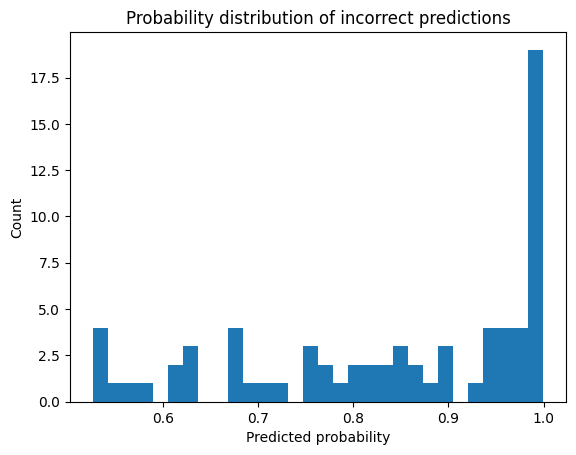

In [122]:
test_dataset[test_dataset["interaction_type"] != test_dataset["prediction"]]["probability"].hist(bins=30)
plt.title("Probability distribution of incorrect predictions")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.grid(False)
plt.show()

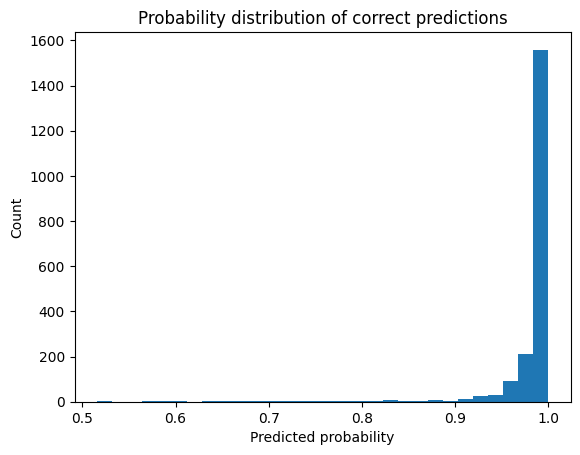

In [121]:
test_dataset[test_dataset["interaction_type"] == test_dataset["prediction"]]["probability"].hist(bins=30)
plt.title("Probability distribution of correct predictions")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.grid(False)
plt.show()